# Healthcare Analytics

### Overview

This project aims to analyze healthcare operational, financial, and quality performance using key performance indicators (KPIs) to support data-driven decision-making and improve hospital efficiency.

### Operational KPIs:
- Average Length of Stay (ALOS): measures the average number of days patients stay in the hospital.
- Bed Occupancy Rate: percentage of occupied beds over total capacity.
- Bed Occupancy Rate Trend
- Emergency Wait Time: average time patients wait in the emergency department.
- Lab Test Turnaround Time: time taken to process lab results.
- Admission Type Distribution (Emergency, Scheduled, Maternity)
- Patient Severity Distribution

### Quality of Care:
- Readmission Rate: percentage of patients readmitted within a defined period.
- Treatment Success Rate: proportion of successful treatments.
- Abnormal Lab Results Test

### Financial KPIs:
- Average Treatment Cost: cost per patient treatment.
- Revenue per Hospital: total income generated.
- Revenue by Hospital Type (Government, Private)
- Operating Margin: profitability indicator.

### Patient Experience:
- Patient Satisfaction Score: reflects patient feedback and experience.
- Patient Satisfaction by Service Dimension (Doctor Communication, Cleanliness, Pain Management, etc.)

### Staff Efficiency:
- Staff Distribution: allocation of staff across departments.
- Saudization Rate.
- Average Salary Cost: cost of workforce.
- Staff Nationality Distribution

### Demographic & Workload KPIs:
- Admissions Distribution by Age Group.
- Average Cost per Age Group.
- Admissions per Department.
- Department Workload Analysis.

In [54]:
# Import all libraries
import pandas as pd   #For working with data tables
import numpy as np    #For mathematical operations
import matplotlib.pyplot as plt   #For creating charts
import seaborn as sns     #For beautiful statistical charts
import warnings       #To hide unnecessary warning messages

# Set display options for better readability
warnings.filterwarnings('ignore')   #Hide warnings to keep output clean
pd.set_option('display.max_columns', None) #Show all columns
pd.set_option('display.max_rows', 100) #Show up to 100 rows
pd.set_option('display.float_format', '{:.2f}'.format)  #Show e decimal places

# Set chart style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

print("All libraries imported successfully!")

All libraries imported successfully!


In [68]:
# Load dataset
data_path = "data/"
# Load master data tables
hospitals = pd.read_csv(data_path + 'hospitals.csv')
departments = pd.read_csv(data_path + 'departments.csv')
patients = pd.read_csv(data_path + 'patients.csv')
medical_staff = pd.read_csv(data_path + 'medical_staff.csv')

# Load transaction tables
admissions = pd.read_csv(data_path + 'admissions.csv')
treatments = pd.read_csv(data_path + 'treatments.csv')
lab_results = pd.read_csv(data_path + 'lab_results.csv')

# Load snapshot / summary tables
bed_occupancy = pd.read_csv(data_path + 'bed_occupancy_snapshots.csv')
satisfaction = pd.read_csv(data_path + 'patient_satisfaction.csv')
kpi_summary = pd.read_csv(data_path + 'kpi_monthly_summary.csv')

print("All 10 datasets loaded successfully!")
print(f"\nDataset sizes:")
print(f"  Hospitals:          {hospitals.shape[0]:,} rows x {hospitals.shape[1]} columns")
print(f"  Departments:        {departments.shape[0]:,} rows x {departments.shape[1]} columns")
print(f"  Patients:           {patients.shape[0]:,} rows x {patients.shape[1]} columns")
print(f"  Medical Staff:      {medical_staff.shape[0]:,} rows x {medical_staff.shape[1]} columns")
print(f"  Admissions:         {admissions.shape[0]:,} rows x {admissions.shape[1]} columns")
print(f"  Treatments:         {treatments.shape[0]:,} rows x {treatments.shape[1]} columns")
print(f"  Lab Results:        {lab_results.shape[0]:,} rows x {lab_results.shape[1]} columns")
print(f"  Bed Occupancy:      {bed_occupancy.shape[0]:,} rows x {bed_occupancy.shape[1]} columns")
print(f"  Patient Satisfaction:{satisfaction.shape[0]:,} rows x {satisfaction.shape[1]} columns")
print(f"  KPI Monthly Summary:{kpi_summary.shape[0]:,} rows x {kpi_summary.shape[1]} columns")

All 10 datasets loaded successfully!

Dataset sizes:
  Hospitals:          15 rows x 9 columns
  Departments:        20 rows x 5 columns
  Patients:           500 rows x 10 columns
  Medical Staff:      400 rows x 13 columns
  Admissions:         3,000 rows x 13 columns
  Treatments:         5,000 rows x 10 columns
  Lab Results:        4,000 rows x 11 columns
  Bed Occupancy:      360 rows x 12 columns
  Patient Satisfaction:2,000 rows x 14 columns
  KPI Monthly Summary:24 rows x 16 columns


In [69]:
#print("=" * 80)
print("Hospitals TABLE (first 5 rows)")
print("=" * 80)
hospitals.head()

Hospitals TABLE (first 5 rows)


,hospital_id,hospital_name,city,region,type,bed_capacity,established_year,accreditation,ownership
0,H001,King Faisal Specialist Hospital,Riyadh,Riyadh Region,Tertiary,1200,1975,JCI Accredited,Government
1,H002,King Abdulaziz Medical City,Jeddah,Makkah Region,Tertiary,950,1982,JCI Accredited,Government
2,H003,Saudi German Hospital,Riyadh,Riyadh Region,General,450,2000,CBAHI Accredited,Private
3,H004,Dr. Sulaiman Al Habib Hospital,Riyadh,Riyadh Region,General,400,2006,JCI Accredited,Private
4,H005,King Fahad Medical City,Riyadh,Riyadh Region,Tertiary,1100,2004,JCI Accredited,Government


In [70]:
#print("=" * 80)
print("Patients TABLE (first 5 rows)")
print("=" * 80)
patients.head()

Patients TABLE (first 5 rows)


,patient_id,first_name,last_name,gender,date_of_birth,nationality,city,blood_type,insurance_type,chronic_conditions
0,PAT0001,Faisal,Al-Qurashi,Male,1949-07-15,Saudi,Makkah,O+,Private (Bupa),Hypertension
1,PAT0002,Lamia,Al-Shamrani,Female,1982-01-09,Saudi,NEOM,B+,Private (Bupa),Diabetes
2,PAT0003,Rami,Salah,Male,1964-05-08,Egyptian,Riyadh,O+,Private (Bupa),NaN
3,PAT0004,Layla,Al-Ahmadi,Female,1987-01-10,Saudi,Makkah,O+,Government (CCHI),NaN
4,PAT0005,Amina,Hassan,Female,1992-03-28,Egyptian,Riyadh,O+,Private (Medgulf),NaN


In [71]:
#print("=" * 80)
print("Admissions TABLE (first 5 rows)")
print("=" * 80)
admissions.head()

Admissions TABLE (first 5 rows)


,admission_id,patient_id,hospital_id,department_id,admission_date,discharge_date,admission_type,diagnosis,severity,length_of_stay_days,total_cost_sar,payment_status,readmission_flag
0,ADM00001,PAT0401,H013,D009,2024-08-29,2024-08-30,Maternity,Cesarean Section,Low,1,3876.46,Pending,0
1,ADM00002,PAT0157,H009,D016,2024-11-27,2024-12-09,Scheduled,Severe Anxiety Disorder,High,12,20216.93,Paid,0
2,ADM00003,PAT0113,H004,D018,2023-08-06,2023-08-09,Scheduled,Gout Attack,Medium,3,14698.09,Paid,0
3,ADM00004,PAT0314,H004,D003,2023-10-22,2023-10-25,Emergency,Pneumonia,Low,3,4274.48,Paid,1
4,ADM00005,PAT0085,H005,D019,2023-06-06,2023-06-16,Emergency,Iron Deficiency Anemia,High,10,41667.91,Pending,0


In [72]:
# checking messing values
datasets= {
    'Hospitals': hospitals,
    'Departments': departments,
    'Patients': patients,
    'Medical Staff': medical_staff,
    'Admissions': admissions,
    'Treatments': treatments,
    'Lab Results': lab_results,
    'Bed Occupancy': bed_occupancy,
    'Satisfaction': satisfaction,
    'KPI Summary': kpi_summary
}

for name, df in datasets.items():
    print(f"\n{'='* 50}")
    print(f"{name}: {df.shape[0]} rows x {df.shape[1]} columns")
    print(f"{'='*50}")
    print("Data Types:")
    print(df.dtypes)
    print(f"Missing values:")
    missing = df.isnull().sum()
    if missing.sum() > 0:
        print(missing[missing > 0])
    else:
        print("  No missing values!")
    print()

# Handle missing values
# chronic_conditions: filled with 'None' (patient has no chronic condition)
# medication_prescribed: filled with 'No Medication'
# discharge_date: kept as NaN because patient may still be admitted


Hospitals: 15 rows x 9 columns
Data Types:
hospital_id         object
hospital_name       object
city                object
region              object
type                object
bed_capacity         int64
established_year     int64
accreditation       object
ownership           object
dtype: object
Missing values:
  No missing values!


Departments: 20 rows x 5 columns
Data Types:
department_id       object
department_name     object
category            object
avg_staff_count      int64
cost_per_day_sar     int64
dtype: object
Missing values:
  No missing values!


Patients: 500 rows x 10 columns
Data Types:
patient_id            object
first_name            object
last_name             object
gender                object
date_of_birth         object
nationality           object
city                  object
blood_type            object
insurance_type        object
chronic_conditions    object
dtype: object
Missing values:
chronic_conditions    149
dtype: int64


Medical Staff: 400 row

In [73]:
still_admitted = admissions['discharge_date'].isnull().sum()
print(f"Patients still admitted (no discharge date): {still_admitted}")
patients['chronic_conditions'] = patients['chronic_conditions'].fillna('None')
treatments['medication_prescribed'] = treatments['medication_prescribed'].fillna('No Medication')
# For length_of_stay, fill missing with median
missing_los = admissions['length_of_stay_days'].isnull().sum()
if missing_los > 0:
    median_los = admissions['length_of_stay_days'].median()
    admissions['length_of_stay_days'] = admissions['length_of_stay_days'].fillna(median_los)

    print(f"Filled {missing_los} missing LOS values with median: {median_los}")
# Check all datasets for remaining missing values
for name, df in datasets.items():
    missing_total = df.isnull().sum().sum()
    if missing_total > 0:
        print(f"\n{name}: {missing_total} remaining missing values")
    else:
        print(f"{name}: Clean - no missing values") 	

print("\nData cleaning complete!")

Patients still admitted (no discharge date): 15
Hospitals: Clean - no missing values
Departments: Clean - no missing values
Patients: Clean - no missing values
Medical Staff: Clean - no missing values

Admissions: 15 remaining missing values
Treatments: Clean - no missing values
Lab Results: Clean - no missing values
Bed Occupancy: Clean - no missing values
Satisfaction: Clean - no missing values
KPI Summary: Clean - no missing values

Data cleaning complete!


In [74]:
# Convert date columns to datetime

patients['date_of_birth'] = pd.to_datetime(patients['date_of_birth'])
medical_staff['hire_date'] = pd.to_datetime(medical_staff['hire_date'])
admissions['admission_date'] = pd.to_datetime(admissions['admission_date'])
admissions['discharge_date'] = pd.to_datetime(admissions['discharge_date'])
treatments['treatment_date'] = pd.to_datetime(treatments['treatment_date'])
lab_results['test_date'] = pd.to_datetime(lab_results['test_date'])
bed_occupancy['snapshot_date'] = pd.to_datetime(bed_occupancy['snapshot_date'])
satisfaction['survey_date'] = pd.to_datetime(satisfaction['survey_date'])
print("All date columns converted successfully!")
print(f"\nAdmission date range: {admissions['admission_date'].min()} to {admissions['admission_date'].max()}")
print(f"Treatment date range: {treatments['treatment_date'].min()} to {treatments['treatment_date'].max()}")

All date columns converted successfully!

Admission date range: 2023-01-01 00:00:00 to 2024-12-31 00:00:00
Treatment date range: 2023-01-01 00:00:00 to 2024-12-31 00:00:00


In [75]:
#Calculate patient age
patients['age']= (pd.Timestamp.today() - patients['date_of_birth']).dt.days//365
#Categorize age
def categorize_age(age):
    if age < 18:
        return 'Pediatric (0-17)'
    elif age < 40:
        return 'Young Adult (18-39)'
    elif age < 60:
        return 'Middle Age (40-59)'
    elif age < 75:
        return 'Senior (60-74)'
    else:
        return 'Elderly (75+)'
patients['age_group']= patients['age'].apply(categorize_age)
print("Patient Age Distribution:")
print(patients['age_group'].value_counts())
print(f"\nAverage age: {patients['age'].mean():.1f} years")
print(f"Youngest patient: {patients['age'].min()} years")
print(f"Oldest patient: {patients['age'].max()} years")

Patient Age Distribution:
age_group
Young Adult (18-39)    162
Middle Age (40-59)     138
Senior (60-74)         102
Pediatric (0-17)        60
Elderly (75+)           38
Name: count, dtype: int64

Average age: 43.9 years
Youngest patient: 3 years
Oldest patient: 80 years


In [76]:
# Adding month and year columns to admissions for time-based analysis
admissions['admission_year']= admissions['admission_date'].dt.year
admissions['admission_month']= admissions['admission_date'].dt.month
admissions['admission_month_name']= admissions['admission_date'].dt.strftime('%b %Y')
# Create a year-month column for grouping
admissions['year_month'] = admissions['admission_date'].dt.to_period('M')
# Create analytical dataset (Data Warehouse Table)
# Adding hospital type
admissions_enriched = admissions.merge(hospitals[['hospital_id','hospital_name','city','type','ownership']], on='hospital_id', how='left')
# Adding department name
admissions_enriched= admissions_enriched.merge(departments[['department_id','department_name','category']], on='department_id', how='left')
# Adding patient demographics
admissions_enriched= admissions_enriched.merge(patients[['patient_id','gender', 'nationality', 'age', 'age_group'
                                               , 'insurance_type', 'chronic_conditions']], on= 'patient_id', how='left')
print(f"Enriched admissions dataset: {admissions_enriched.shape[0]} rows x {admissions_enriched.shape[1]} columns")
print(f"\nNew columns added: hospital_name, city, type, ownership, department_name,")
print(f"category, gender, nationality, age, age_group, insurance_type, chronic_conditions")
admissions_enriched.head(3)

Enriched admissions dataset: 3000 rows x 29 columns

New columns added: hospital_name, city, type, ownership, department_name,
category, gender, nationality, age, age_group, insurance_type, chronic_conditions


,admission_id,patient_id,hospital_id,department_id,admission_date,discharge_date,admission_type,diagnosis,severity,length_of_stay_days,total_cost_sar,payment_status,readmission_flag,admission_year,admission_month,admission_month_name,year_month,hospital_name,city,type,ownership,department_name,category,gender,nationality,age,age_group,insurance_type,chronic_conditions
0,ADM00001,PAT0401,H013,D009,2024-08-29,2024-08-30,Maternity,Cesarean Section,Low,1,3876.46,Pending,0,2024,8,Aug 2024,2024-08,King Khalid University Hospital,Riyadh,Teaching,Government,Neurology,Medical,Female,Pakistani,59,Middle Age (40-59),Government (CCHI),None
1,ADM00002,PAT0157,H009,D016,2024-11-27,2024-12-09,Scheduled,Severe Anxiety Disorder,High,12,20216.93,Paid,0,2024,11,Nov 2024,2024-11,King Fahad Hospital,Dammam,General,Government,Nephrology,Medical,Male,Saudi,34,Young Adult (18-39),Military (GOSI),Obesity
2,ADM00003,PAT0113,H004,D018,2023-08-06,2023-08-09,Scheduled,Gout Attack,Medium,3,14698.09,Paid,0,2023,8,Aug 2023,2023-08,Dr. Sulaiman Al Habib Hospital,Riyadh,General,Private,ENT,Surgical,Female,Saudi,49,Middle Age (40-59),Private (Bupa),Hypertension


In [77]:
# Saving Data
admissions_enriched.to_csv('data/admissions_enriched.csv', index=False)
print("Enriched admissions data saved to: data/admissions_enriched.csv")
print(f"Total columns: {admissions_enriched.shape[1]}")
print(f"Total rows: {admissions_enriched.shape[0]}")

Enriched admissions data saved to: data/admissions_enriched.csv
Total columns: 29
Total rows: 3000


### KPI 1 - Average Length of Stay (ALOS)

In [78]:
# Average LOS
alos= admissions_enriched['length_of_stay_days'].mean()
# ALOS by severity
alos_by_severity= admissions_enriched.groupby('severity')['length_of_stay_days'].mean()
alos_by_hospital= admissions_enriched.groupby('hospital_name')['length_of_stay_days'].mean()
print("=" * 50)
print("KPI 1: AVERAGE LENGTH OF STAY (ALOS)")
print("=" * 50)
print(f"\nOverall ALOS: {alos:.2f} days")
print(f"\nALOS by Severity:")
for severity, days in alos_by_severity.items():
    status = "GOOD" if days < 7 else "MONITOR" if days < 14 else "HIGH"
    print(f"  {severity}: {days:.2f} days [{status}]")

print(f"\nTop 5 Hospitals with Lowest ALOS (Best):")
for hospital, days in alos_by_hospital.head().items():
    print(f"  {hospital}: {days:.2f} days")

KPI 1: AVERAGE LENGTH OF STAY (ALOS)

Overall ALOS: 7.97 days

ALOS by Severity:
  Critical: 29.46 days [HIGH]
  High: 10.65 days [MONITOR]
  Low: 2.00 days [GOOD]
  Medium: 5.01 days [GOOD]

Top 5 Hospitals with Lowest ALOS (Best):
  Al Hammadi Hospital: 7.03 days
  Al Noor Specialist Hospital: 9.80 days
  Dallah Hospital: 7.72 days
  Dr. Sulaiman Al Habib Hospital: 7.71 days
  King Abdulaziz Medical City: 8.11 days


### KPI 2 - Bed Occupancy Rate (BOR)

In [86]:
#BOR shows how efficiently hospital beds are being used.
#Formula: Occupied Beds / Total Beds x 100
#Industry Benchmark: 80-85% is optimal (too high means overcrowding, too low means waste)
bor = bed_occupancy['occupancy_rate'].mean()
occupancy_by_hospital= bed_occupancy.groupby('hospital_id')['occupancy_rate'].mean()
occupancy_with_names= occupancy_by_hospital.reset_index().merge(hospitals[['hospital_id','hospital_name','ownership']],on='hospital_id',how='left').sort_values('occupancy_rate',ascending=False)
print("=" * 50)
print("KPI 2: BED OCCUPANCY RATE")1200
print("=" * 50)
print(f"\nOverall Average Occupancy: {bor:.1%}")

status = "OPTIMAL" if 0.80 <= bor <= 0.85 else "HIGH" if bor > 0.85 else "LOW"
print(f"Status: {status}")

print(f"\nOccupancy by Hospital:")
for _, row in occupancy_with_names.iterrows():
    occ = row['occupancy_rate']
    flag = "OVERCROWDED" if occ > 0.90 else "OPTIMAL" if occ >= 0.80 else "UNDERUSED"
    print(f"  {row['hospital_name']}: {occ:.1%} [{flag}]")

KPI 2: BED OCCUPANCY RATE

Overall Average Occupancy: 78.7%
Status: LOW

Occupancy by Hospital:
  Prince Sultan Military Medical City: 85.4% [OPTIMAL]
  King Fahad Medical City: 84.7% [OPTIMAL]
  King Faisal Specialist Hospital: 84.5% [OPTIMAL]
  King Abdulaziz Medical City: 84.3% [OPTIMAL]
  King Khalid University Hospital: 83.9% [OPTIMAL]
  Magrabi Eye Hospital: 82.5% [OPTIMAL]
  Al Noor Specialist Hospital: 81.9% [OPTIMAL]
  King Abdullah Medical Complex: 81.5% [OPTIMAL]
  King Fahad Hospital: 76.6% [UNDERUSED]
  Saudi German Hospital: 75.5% [UNDERUSED]
  Al Hammadi Hospital: 75.2% [UNDERUSED]
  Mouwasat Medical Services: 74.9% [UNDERUSED]
  Dallah Hospital: 74.8% [UNDERUSED]
  Dr. Sulaiman Al Habib Hospital: 74.5% [UNDERUSED]
  NEOM Health Center: 60.0% [UNDERUSED]


### KPI 3 - 30-Day Readmission Rate

In [93]:
#Readmission rate measures how often patients return within 30 days. Lower is better.
#Formula: Readmissions within 30 days / Total Discharges x 100
#Industry Benchmark: Below 10% is good
readmission_rate= admissions['readmission_flag'].mean()
readmission_by_dept= admissions_enriched.groupby('department_name')['readmission_flag'].mean().sort_values(ascending=False)
readmission_by_hospital= admissions_enriched.groupby('hospital_name')['readmission_flag'].mean().sort_values(ascending=False)
print("=" * 50)
print("KPI 3: 30-DAY READMISSION RATE")
print("=" * 50)
print(f"\nOverall Readmission Rate: {readmission_rate:.1%}")
status = "GOOD" if readmission_rate < 0.10 else "MONITOR" if readmission_rate < 0.15 else "POOR"
print(f"Status: {status}")

print(f"\nReadmission by Department (Top 5 Highest):")
for dept, rate in readmission_by_dept.head().items():
    print(f"  {dept}: {rate:.1%}")

KPI 3: 30-DAY READMISSION RATE

Overall Readmission Rate: 14.9%
Status: MONITOR

Readmission by Department (Top 5 Highest):
  General Surgery: 21.1%
  Dermatology: 20.1%
  Emergency Medicine: 20.1%
  Orthopedics: 19.3%
  Psychiatry: 18.5%


### KPI 4 - Patient Satisfaction Score

In [102]:
#Patient satisfaction directly impacts hospital reputation and revenue.
#Formula: Average of all satisfaction survey ratings (1-5 scale)
#Industry Benchmark: Above 4.0 is excellent, 3.5-4.0 is good
avg_satisfaction = satisfaction['overall_rating'].mean()
satisfaction_by_hospital = satisfaction.merge(hospitals[['hospital_id','hospital_name','ownership']],on='hospital_id').groupby(['hospital_name','ownership'])['overall_rating'].mean().sort_values(ascending=False)
print("=" * 50)
print("KPI 4: PATIENT SATISFACTION SCORE")
print("=" * 50)
print(f"\nOverall Average : {avg_satisfaction:.2f}/5.0")
status= "EXCELLENT" if avg_satisfaction >= 4.0 else "GOOD" if avg_satisfaction >= 3.5 else "NEEDS IMPROVEMENTS"
print(f"\nStatus : {status}")
print(f"\nSatisfaction By Hospital:")
for (hospital, ownership), score in satisfaction_by_hospital.items():
    emoji_status= "EXCELLENT" if score >= 4.0 else "GOOD" if score >= 3.5 else "IMPROVE"
    print(f"{hospital} ({ownership}): {score:.2f} [{emoji_status}]")
#Private vs Government Comparison
private_avg = satisfaction.merge(hospitals, on= 'hospital_id').query("ownership == 'Private'")["overall_rating"].mean()
govt_avg = satisfaction.merge(hospitals, on= 'hospital_id').query("ownership == 'Government'")["overall_rating"].mean()
print(f"\nPrivate Hospitals Average:{private_avg:.2f}")
print(f"\nGovernment Hospitals Average:{govt_avg:.2f}")

KPI 4: PATIENT SATISFACTION SCORE

Overall Average : 3.86/5.0

Status : GOOD

Satisfaction By Hospital:
Saudi German Hospital (Private): 4.18 [EXCELLENT]
Mouwasat Medical Services (Private): 4.11 [EXCELLENT]
Al Noor Specialist Hospital (Private): 4.09 [EXCELLENT]
Al Hammadi Hospital (Private): 4.05 [EXCELLENT]
Dallah Hospital (Private): 4.03 [EXCELLENT]
King Fahad Hospital (Government): 4.00 [EXCELLENT]
Dr. Sulaiman Al Habib Hospital (Private): 3.98 [GOOD]
Magrabi Eye Hospital (Private): 3.94 [GOOD]
NEOM Health Center (Government): 3.74 [GOOD]
King Fahad Medical City (Government): 3.73 [GOOD]
King Abdullah Medical Complex (Government): 3.71 [GOOD]
King Faisal Specialist Hospital (Government): 3.67 [GOOD]
Prince Sultan Military Medical City (Government): 3.65 [GOOD]
King Abdulaziz Medical City (Government): 3.60 [GOOD]
King Khalid University Hospital (Government): 3.56 [GOOD]

Private Hospitals Average:4.06

Government Hospitals Average:3.70


### KPI 5 - Emergency Wait Time

In [109]:
emergancy_satisfaction = satisfaction.merge(departments[['department_id', 'department_name']], on = 'department_id')
avg_wait = satisfaction['wait_time_minutes'].mean()
wait_by_dep = emergancy_satisfaction.groupby('department_name')['wait_time_minutes'].mean().sort_values(ascending=False)
print("=" * 50)
print("KPI 5: AVERAGE WAIT TIME")
print("=" * 50)
print(f"\nOverall Average Wait Time: {avg_wait:.0f} minutes")
status = "GOOD" if avg_wait < 45 else "MONITOR" if avg_wait < 60 else "POOR"
print(f"Status: {status}")
print(f"\nWait Time by Department (Top 10):")
for dept, minutes in wait_by_dep.head(10).items():
    flag = "CRITICAL" if minutes > 90 else "HIGH" if minutes > 60 else "OK"
    print(f"  {dept}: {minutes:.0f} min [{flag}]")

KPI 5: AVERAGE WAIT TIME

Overall Average Wait Time: 52 minutes
Status: MONITOR

Wait Time by Department (Top 10):
  Emergency Medicine: 116 min [CRITICAL]
  Psychiatry: 114 min [CRITICAL]
  Cardiology: 113 min [CRITICAL]
  Radiology: 113 min [CRITICAL]
  Oncology: 39 min [OK]
  Ophthalmology: 39 min [OK]
  General Surgery: 38 min [OK]
  Pathology & Laboratory: 38 min [OK]
  Internal Medicine: 37 min [OK]
  Rehabilitation: 37 min [OK]


### KPI 6 - Treatment Success Rate

In [111]:
success_rate = (treatments['outcome'] == "Successful") .mean()
success_by_type = treatments.groupby('treatment_type')['outcome'].apply(lambda x: (x=="Successful").mean()).sort_values(ascending=False)
complications_rate = (treatments['outcome'] == 'Complications').mean()
print("=" * 50)
print("KPI 6: TREATMENT SUCCESS RATE")
print("=" * 50)
print(f"\nOverall Success Rate: {success_rate:.1%}")
print(f"Complications Rate: {complications_rate:.1%}")
print(f"\nSuccess Rate by Treatment Type:")
for ttype, rate in success_by_type.items():
    print(f"  {ttype}: {rate:.1%}")

KPI 6: TREATMENT SUCCESS RATE

Overall Success Rate: 70.0%
Complications Rate: 4.6%

Success Rate by Treatment Type:
  Therapy: 71.6%
  Procedure: 71.2%
  Surgery: 70.3%
  Diagnostic Test: 69.8%
  Medication: 69.1%


### KPI 7 - Revenue & Cost Analysis

In [114]:
total_revenue = admissions['total_cost_sar'].sum()
avg_cost_per_admission = admissions['total_cost_sar'].mean()
revenue_per_hospital = admissions_enriched.groupby('hospital_name')['total_cost_sar'].agg(['sum', 'mean', 'count'])
revenue_per_hospital.columns = ['total_revenue', 'avg_per_admission', 'total_admissions']
revenue_per_hospital = revenue_per_hospital.sort_values('total_revenue', ascending= False)
print("=" * 50)
print("KPI 7: REVENUE & COST ANALYSIS")
print("=" * 50)
print(f"\nTotal Revenue (2 years): SAR {total_revenue:,.0f}")
print(f"Average Cost per Admission: SAR {avg_cost_per_admission:,.0f}")
print(f"\nRevenue by Hospital (Top 10):")
for hospital, row in revenue_per_hospital.head(10).iterrows():
    print(f"  {hospital}:")
    print(f"    Total Revenue: SAR {row['total_revenue']:,.0f}")
    print(f"    Avg per Admission: SAR {row['avg_per_admission']:,.0f}")
    print(f"    Total Admissions: {row['total_admissions']:,.0f}")

KPI 7: REVENUE & COST ANALYSIS

Total Revenue (2 years): SAR 101,788,760
Average Cost per Admission: SAR 33,930

Revenue by Hospital (Top 10):
  Dr. Sulaiman Al Habib Hospital:
    Total Revenue: SAR 10,787,176
    Avg per Admission: SAR 34,685
    Total Admissions: 311
  King Abdulaziz Medical City:
    Total Revenue: SAR 9,799,668
    Avg per Admission: SAR 35,124
    Total Admissions: 279
  NEOM Health Center:
    Total Revenue: SAR 8,180,237
    Avg per Admission: SAR 34,662
    Total Admissions: 236
  King Fahad Hospital:
    Total Revenue: SAR 7,897,089
    Avg per Admission: SAR 39,289
    Total Admissions: 201
  King Faisal Specialist Hospital:
    Total Revenue: SAR 6,943,180
    Avg per Admission: SAR 34,716
    Total Admissions: 200
  King Abdullah Medical Complex:
    Total Revenue: SAR 6,860,708
    Avg per Admission: SAR 29,700
    Total Admissions: 231
  King Khalid University Hospital:
    Total Revenue: SAR 6,798,482
    Avg per Admission: SAR 38,410
    Total Admissio

### KPI 8-12 - Additional KPIs

In [220]:
# KPI 8: Lab Test Turnaround Time
avg_turnaround = lab_results['turnaround_hours'].mean()
turnaround_by_test = lab_results.groupby('test_name')['turnaround_hours'].mean().sort_values(ascending = False)
# KPI 9: Abnormal Lab Results Rate
abnormal_rate = lab_results['status'].isin(['Abnormal High','Abnormal Low','Critical']).mean()
critical_rate = (lab_results['status'] == "Critical").mean()
# KPI 10: Staff Distribution
staff_by_role = medical_staff.groupby('role').size()
active_staff = medical_staff[medical_staff['employment_status']== "Active"]
saudi_ratio = (medical_staff['nationality'] == 'Saudi').mean()
# KPI 11: Insurance Distribution
insurance_dist = admissions_enriched['insurance_type'].value_counts(normalize = True)
# KPI 12: Monthly Admission Trend
monthly_trend = admissions.groupby(['admission_year','admission_month']).size().reset_index(name='count')
print("=" * 50)
print("ADDITIONAL HEALTHCARE KPIs (8-12)")
print("=" * 50)

print(f"\nKPI 8: Lab Turnaround Time")
print(f"  Average: {avg_turnaround:.1f} hours")

print(f"\nKPI 9: Abnormal Lab Results")
print(f"  Abnormal Rate: {abnormal_rate:.1%}")
print(f"  Critical Rate: {critical_rate:.1%}")

print(f"\nKPI 10: Staff Distribution")
for role, count in staff_by_role.items():
    print(f"  {role}: {count}")
print(f"  Saudization Rate: {saudi_ratio:.1%}")

print(f"\nKPI 11: Insurance Distribution")
for insurance, pct in insurance_dist.items():
    print(f"  {insurance}: {pct:.1%}")
print(f"\nKPI 12: Monthly Admission Trend")
for _, row in monthly_trend.iterrows():
    print(f"Year {int(row['admission_year'])} - Month {int(row['admission_month'])}: {row['count']} admissions")

ADDITIONAL HEALTHCARE KPIs (8-12)

KPI 8: Lab Turnaround Time
  Average: 8.3 hours

KPI 9: Abnormal Lab Results
  Abnormal Rate: 38.8%
  Critical Rate: 7.8%

KPI 10: Staff Distribution
  Administrator: 40
  Doctor: 100
  Nurse: 160
  Specialist: 60
  Technician: 40
  Saudization Rate: 55.0%

KPI 11: Insurance Distribution
  Government (CCHI): 24.3%
  Private (Tawuniya): 19.1%
  Military (GOSI): 15.7%
  Private (Bupa): 14.6%
  Private (Medgulf): 14.4%
  Self-Pay: 12.0%

KPI 12: Monthly Admission Trend
Year 2023 - Month 1: 117 admissions
Year 2023 - Month 2: 93 admissions
Year 2023 - Month 3: 104 admissions
Year 2023 - Month 4: 96 admissions
Year 2023 - Month 5: 138 admissions
Year 2023 - Month 6: 189 admissions
Year 2023 - Month 7: 165 admissions
Year 2023 - Month 8: 160 admissions
Year 2023 - Month 9: 116 admissions
Year 2023 - Month 10: 104 admissions
Year 2023 - Month 11: 88 admissions
Year 2023 - Month 12: 131 admissions
Year 2024 - Month 1: 107 admissions
Year 2024 - Month 2: 80 ad

### KPI Summary Dashboard

In [122]:
kpi_data= {
    'KPI':[
        'Average Length of Stay (ALOS)',
        'Bed Occupancy Rate',
        '30-Day Readmission Rate',
        'Patient Satisfaction Score',
        'Average Wait Time',
        'Treatment Success Rate',
        'Complications Rate',
        'Average Cost per Admission',
        'Lab Turnaround Time',
        'Abnormal Lab Results Rate',
        'Saudization Rate (Staff)',
        'Total Revenue (2 Years)'
    ],
    'Value':[
        f"{alos:.2f} days",
        f"{bor:.1%}",
        f"{readmission_rate:.1%}",
        f"{avg_satisfaction:.2f} / 5.0",
        f"{avg_wait:.0f} minutes",
        f"{success_rate:.1%}",
        f"{complications_rate:.1%}",
        f"SAR {avg_cost_per_admission:,.0f}",
        f"{avg_turnaround:.1f} hours",
        f"{abnormal_rate:.1%}",
        f"{saudi_ratio:.1%}",
        f"SAR {total_revenue:,.0f}"
    ],
    'Benchmark':[
        '4-5 days',
        '80-85%',
        'Below 10%',
        'Above 4.0',
        'Below 45 min',
        'Above 90%',
        'Below 3%',
        'Varies',
        'Below 24 hrs',
        'Below 25%',
        'Above 55% (Nitaqat)',
        'N/A'
    ],
    'Status':[
        'GOOD' if alos < 5 else 'MONITOR',
        'OPTIMAL' if 0.80 <= bor <= 0.85 else 'MONITOR',
        'GOOD' if readmission_rate < 0.10 else 'MONITOR',
        'GOOD' if avg_satisfaction >= 3.5 else 'IMPROVE',
        'GOOD' if avg_wait < 45 else 'MONITOR',
        'GOOD' if success_rate > 0.90 else 'MONITOR',
        'GOOD' if complications_rate < 0.03 else 'MONITOR',
        'N/A',
        'GOOD' if avg_turnaround < 24 else 'MONITOR',
        'GOOD' if abnormal_rate < 0.25 else 'MONITOR',
        'GOOD' if saudi_ratio >= 0.55 else 'BELOW TARGET',
        'N/A'
    ]
}
kpi_dashboard = pd.DataFrame(kpi_data)
print("\n" + "=" * 80)
print("HEALTHCARE KPI DASHBOARD - SAUDI HOSPITALS (2023-2024)")
print("=" * 80)
print(kpi_dashboard.to_string(index=False))
# Save KPI dashboard to Excel
kpi_dashboard.to_excel('Healthcare_KPI_Dashboard.xlsx', index=False, sheet_name='KPI Summary')
print("\nKPI Dashboard saved to: Healthcare_KPI_Dashboard.xlsx")


HEALTHCARE KPI DASHBOARD - SAUDI HOSPITALS (2023-2024)
                          KPI           Value           Benchmark  Status
Average Length of Stay (ALOS)       7.97 days            4-5 days MONITOR
           Bed Occupancy Rate           78.7%              80-85% MONITOR
      30-Day Readmission Rate           14.9%           Below 10% MONITOR
   Patient Satisfaction Score      3.86 / 5.0           Above 4.0    GOOD
            Average Wait Time      52 minutes        Below 45 min MONITOR
       Treatment Success Rate           70.0%           Above 90% MONITOR
           Complications Rate            4.6%            Below 3% MONITOR
   Average Cost per Admission      SAR 33,930              Varies     N/A
          Lab Turnaround Time       8.3 hours        Below 24 hrs    GOOD
    Abnormal Lab Results Rate           38.8%           Below 25% MONITOR
     Saudization Rate (Staff)           55.0% Above 55% (Nitaqat)    GOOD
      Total Revenue (2 Years) SAR 101,788,760           

### Exploratory Data Analysis

In [126]:
# Analyze admissions by hospital ownership type
ownership_analysis = admissions_enriched.groupby('ownership').agg({'admission_id':'count', 'total_cost_sar':['sum','mean'],'length_of_stay_days':'mean','readmission_flag':'mean'}).round(2)
ownership_analysis.columns=['Total Admission', 'Total Ravenue (SAR)', 'Avg Cost (SAR)', 'Avg LOS (Days)', 'Readmission Rate']
print("Analysis: Government Vs Private Hospitals ")
print("="*60)
print(ownership_analysis.to_string())

Analysis: Government Vs Private Hospitals 
            Total Admission  Total Ravenue (SAR)  Avg Cost (SAR)  Avg LOS (Days)  Readmission Rate
ownership                                                                                         
Government             1711          58395719.95        34129.59            7.97              0.15
Private                1289          43393039.71        33664.11            7.97              0.14


In [127]:
# Seasonal analysis - Hajj season impact
monthly_admissions = admissions_enriched.groupby(['admission_year','admission_month']).agg({
    'admission_id':'count',
    'total_cost_sar':'mean',
    'length_of_stay_days':'mean'
}).reset_index()
monthly_admissions.columns=['Year','Month','Admissions','Avg Cost','Avg LOS']
# Flag Hajj Month
# Hajj Months are Shawwal, Dhul_Qidah, and Dhul_Hijjah, we will use the approximate equivelaent Calender months
monthly_admissions['Season'] = monthly_admissions['Month'].apply( lambda x: 'Hajj Season (Apr-Jun)' if x in [4,5,6] else 'Regular Season')
season_comparison = monthly_admissions.groupby('Season').agg({'Admissions':'mean', 'Avg Cost': 'mean', 'Avg LOS': 'mean'}).round(2)
print("ANALYSIS: Hajj Season vs Regular Season Impact")
print("=" * 60)
print(season_comparison.to_string())
print(f"\nHajj season increases admissions by approximately "
      f"{((season_comparison.loc['Hajj Season (Apr-Jun)', 'Admissions'] / season_comparison.loc['Regular Season', 'Admissions']) - 1) * 100:.1f}%")

ANALYSIS: Hajj Season vs Regular Season Impact
                       Admissions  Avg Cost  Avg LOS
Season                                              
Hajj Season (Apr-Jun)      131.83  33499.77     8.01
Regular Season             122.72  34550.35     8.00

Hajj season increases admissions by approximately 7.4%


In [132]:
# Chronic conditions impact analysis
chronic_analysis = admissions_enriched.groupby('chronic_conditions').agg({
    'admission_id':'count',
    'total_cost_sar':'mean',
    'length_of_stay_days':'mean',
    'readmission_flag':'mean'
}).round(2)
chronic_analysis.columns=['Total Admissions','Avg Cost (SAR)','Avg LOS (Days)','Readmission Rate']
chronic_analysis = chronic_analysis.sort_values('Total Admissions', ascending=False)
print("ANALYSIS: Impact of Chronic Conditions on Hospital Metrics")
print("=" * 70)
print(chronic_analysis.to_string())
print(f"\nKey Insight: Patients with chronic conditions have higher costs and longer stays")

ANALYSIS: Impact of Chronic Conditions on Hospital Metrics
                         Total Admissions  Avg Cost (SAR)  Avg LOS (Days)  Readmission Rate
chronic_conditions                                                                         
None                                  917        36642.46            8.21              0.15
Diabetes                              449        31646.30            7.59              0.18
Hypertension                          416        30017.79            7.66              0.16
Diabetes & Hypertension               295        33961.31            8.12              0.14
Asthma                                275        30422.00            7.53              0.15
Obesity                               209        37806.45            8.65              0.11
Thyroid Disorder                      136        33820.02            7.96              0.14
Heart Disease                         125        29291.56            7.33              0.11
Kidney Disease       

In [135]:
# Department performance analysis
dept_performance = admissions_enriched.groupby('department_name').agg({
    'admission_id':'count',
    'total_cost_sar':['sum','mean'],
    'length_of_stay_days':'mean',
    'readmission_flag':'mean'
}).round(2)
dept_performance.columns = ['Admissions','Total Revenue','Avg Cost','Avg LOS','Readmission Rate']
dept_performance = dept_performance.sort_values('Admissions', ascending=False)
print("ANALYSIS: Department Performance Comparison")
print("=" * 80)
print(dept_performance.head(15).to_string())

ANALYSIS: Department Performance Comparison
                        Admissions  Total Revenue  Avg Cost  Avg LOS  Readmission Rate
department_name                                                                       
Neurology                      432    14848686.59  34371.96     8.05              0.13
Oncology                       160     5543294.72  34645.59     8.93              0.15
Ophthalmology                  155     5244914.26  33838.16     8.73              0.16
ENT                            154     5461212.93  35462.42     8.85              0.11
General Surgery                147     3864366.47  26288.21     7.02              0.21
Emergency Medicine             144     5506581.31  38240.15     7.01              0.20
Cardiology                     144     4168356.10  28946.92     7.99              0.12
Dermatology                    144     4320242.65  30001.69     8.77              0.20
Pathology & Laboratory         142     5704794.71  40174.61     9.13              0.15

In [140]:
# Insurance type impact analysis
insurance_analysis = admissions_enriched.groupby('insurance_type').agg({
    'admission_id':'count',
    'total_cost_sar':['sum','mean'],
    'length_of_stay_days':'mean'
}).round(2)
insurance_analysis.columns = ['Admissions','Total Cost','Avg Cost','Avg LOS']
insurance_analysis = insurance_analysis.sort_values('Admissions',ascending=False)
print("ANALYSIS: Insurance Type Distribution")
print("=" * 60)
print(insurance_analysis.to_string())
# Self-pay vs insured comparison
self_pay_cost = admissions_enriched[admissions_enriched['insurance_type'] == 'Self-Pay']['total_cost_sar'].mean()
insured_cost = admissions_enriched[admissions_enriched['insurance_type']!= 'Self-Pay']['total_cost_sar'].mean()
print(f"\nAverage cost - Self-Pay: SAR {self_pay_cost:,.0f}")
print(f"Average cost - Insured: SAR {insured_cost:,.0f}")

ANALYSIS: Insurance Type Distribution
                    Admissions  Total Cost  Avg Cost  Avg LOS
insurance_type                                               
Government (CCHI)          729 24141788.70  33116.31     7.98
Private (Tawuniya)         572 19395263.86  33907.80     8.11
Military (GOSI)            470 16455810.08  35012.36     8.21
Private (Bupa)             438 14648529.28  33444.13     7.91
Private (Medgulf)          431 15118467.25  35077.65     7.71
Self-Pay                   360 12028900.49  33413.61     7.79

Average cost - Self-Pay: SAR 33,414
Average cost - Insured: SAR 34,000


### Chart 1 - Monthly Admissions Trend

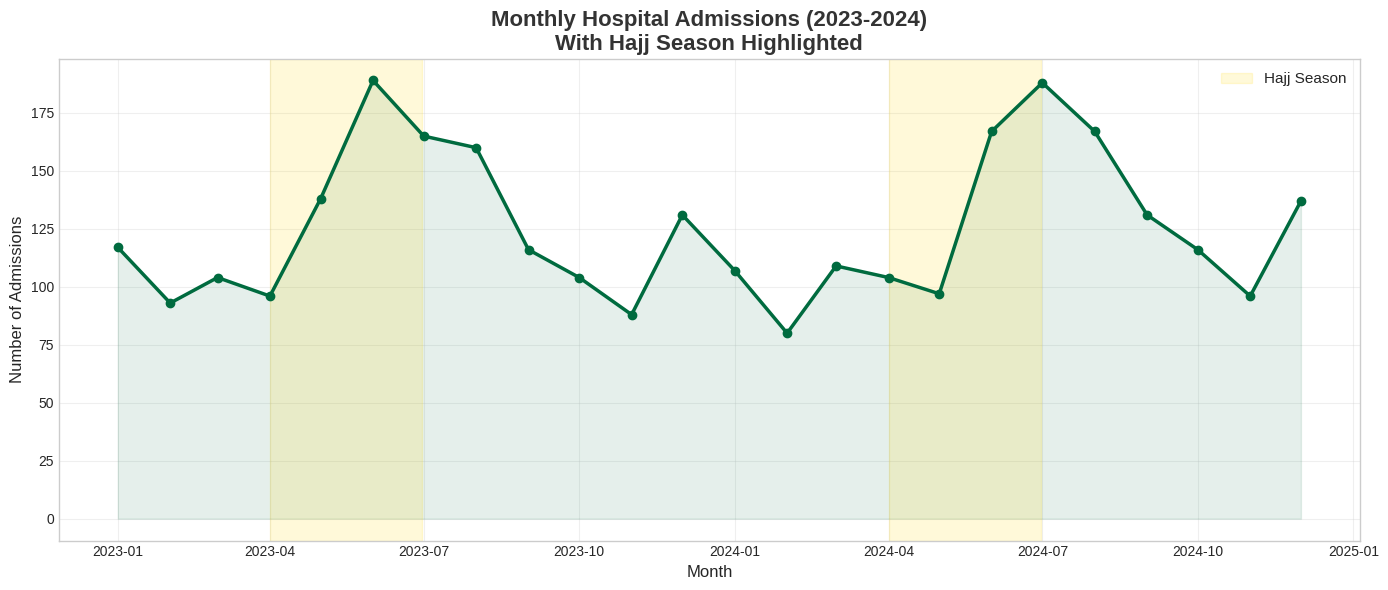

Chart saved: charts/01_monthly_admissions_trend.png


In [145]:
# Monthly Admissions Trend with Hajj Season Highlight
fig, ax = plt.subplots(figsize=(14,6))
monthly = admissions.groupby('year_month').size()
monthly.index = monthly.index.to_timestamp()
ax.plot(monthly.index,monthly.values,color='#006B3F', linewidth=2.5, marker='o', markersize=6)
ax.fill_between(monthly.index,monthly.values,alpha=0.1, color='#006B3F')
# Highlight Hajj season months
for year in [2023,2024]:
    hajj_start= pd.Timestamp(f'{year}-04-01')
    hajj_end= pd.Timestamp(f'{year}-06-30')
    ax.axvspan(hajj_start, hajj_end, alpha=0.15, color='#FFD700', label='Hajj Season' if year == 2023 else '')
ax.set_title('Monthly Hospital Admissions (2023-2024)\nWith Hajj Season Highlighted',fontsize=16, fontweight='bold', color='#333333')
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Number of Admissions', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('charts/01_monthly_admissions_trend.png', dpi=300, bbox_inches='tight')
plt.show()
print("Chart saved: charts/01_monthly_admissions_trend.png")

### Chart 2 - Hospital Revenue Comparison

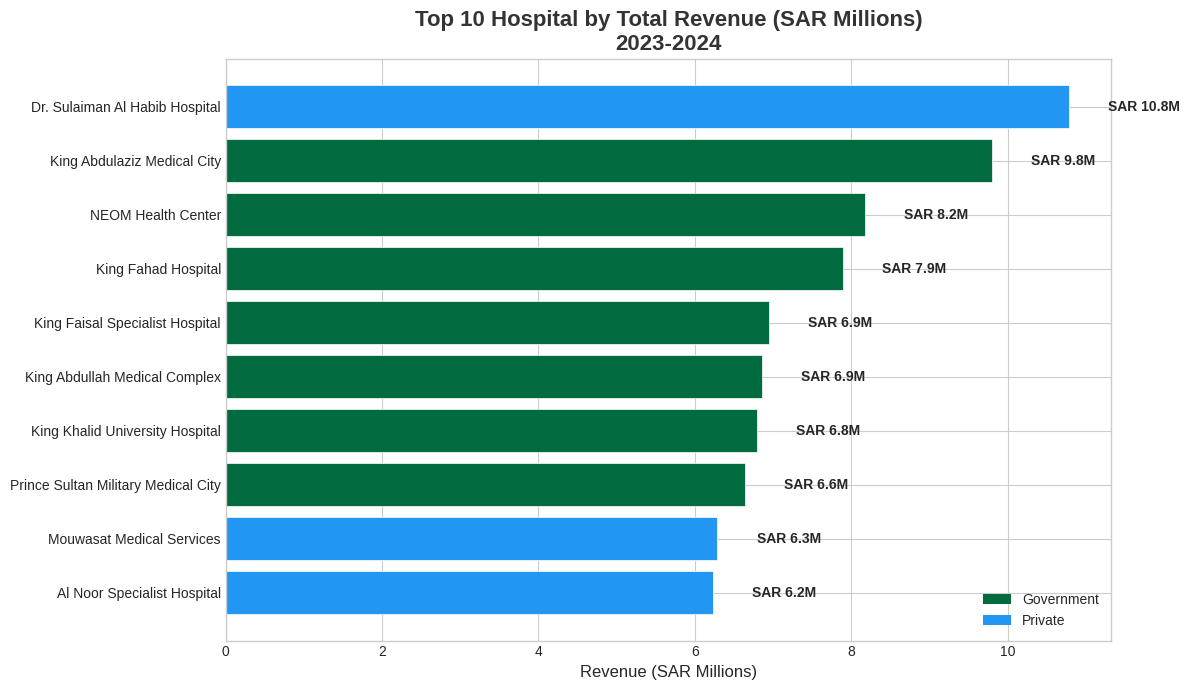

Chart saved: 02_hospital_revenue_comparison.png


In [153]:
from matplotlib.patches import Patch
fig,ax = plt.subplots(figsize=(12,7))
revenue = admissions_enriched.groupby('hospital_name')['total_cost_sar'].sum().sort_values(ascending=True).tail(10)
hospital_ownership = (
    admissions_enriched
    .drop_duplicates('hospital_name')
    .set_index('hospital_name')['ownership']
)

colors = [
    '#006B3F' if hospital_ownership[name] == 'Government' else '#2196F3'
    for name in revenue.index
]
bars = ax.barh(revenue.index,revenue.values/ 1e6, color= colors, edgecolor='white', linewidth=0.5)
ax.set_title('Top 10 Hospital by Total Revenue (SAR Millions)\n2023-2024', fontsize=16, fontweight= 'bold',color = '#333333')
ax.set_xlabel('Revenue (SAR Millions)', fontsize=12)
# Add Value Labels on Bars
for bar , val in zip(bars,revenue.values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, f'SAR {val/1e6:.1f}M',va='center', fontsize= 10, fontweight= 'bold')

legend_elements = [
    Patch(facecolor='#006B3F', label='Government'),
    Patch(facecolor='#2196F3', label='Private')
]

ax.legend(handles=legend_elements, fontsize=10, loc='lower right')
plt.tight_layout()
plt.savefig('charts/02_hospital_revenue_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("Chart saved: 02_hospital_revenue_comparison.png")

### Chart 3 - Patient Satisfaction Heatmap

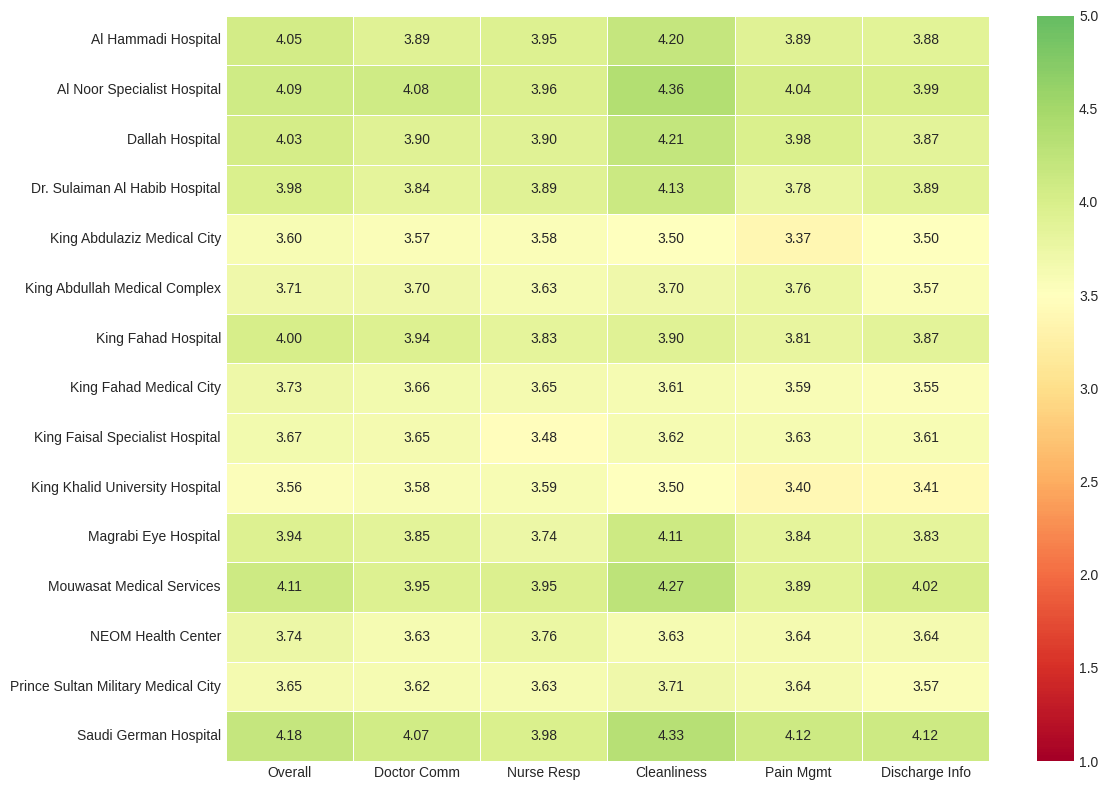

Chart saved: charts/03_satisfaction_heatmap.png


In [163]:
fig. ax= plt.subplots(figsize=(12,8))
sat_cols = ['overall_rating','doctor_communication','nurse_responsiveness','cleanliness','pain_management','discharge_info']
sat_by_hospital = satisfaction.merge(hospitals[['hospital_id','hospital_name']],on= 'hospital_id')
heatmap_data = sat_by_hospital.groupby('hospital_name')[sat_cols].mean()
# Rename columns for display
heatmap_data.columns = ['Overall', 'Doctor Comm', 'Nurse Resp', 'Cleanliness', 'Pain Mgmt', 'Discharge Info']
sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='RdYlGn', center=3.5, vmin= 1, vmax= 5, linewidth= 0.5)
ax.set_title('Patient Satisfaction Scores by Hospital\n(1=Poor, 5=Excellent)',
             fontsize=16, fontweight='bold', color='#333333')
plt.ylabel('')
plt.tight_layout()
plt.savefig('charts/03_satisfaction_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print("Chart saved: charts/03_satisfaction_heatmap.png")

### Chart 4 - Admission Type Distribution

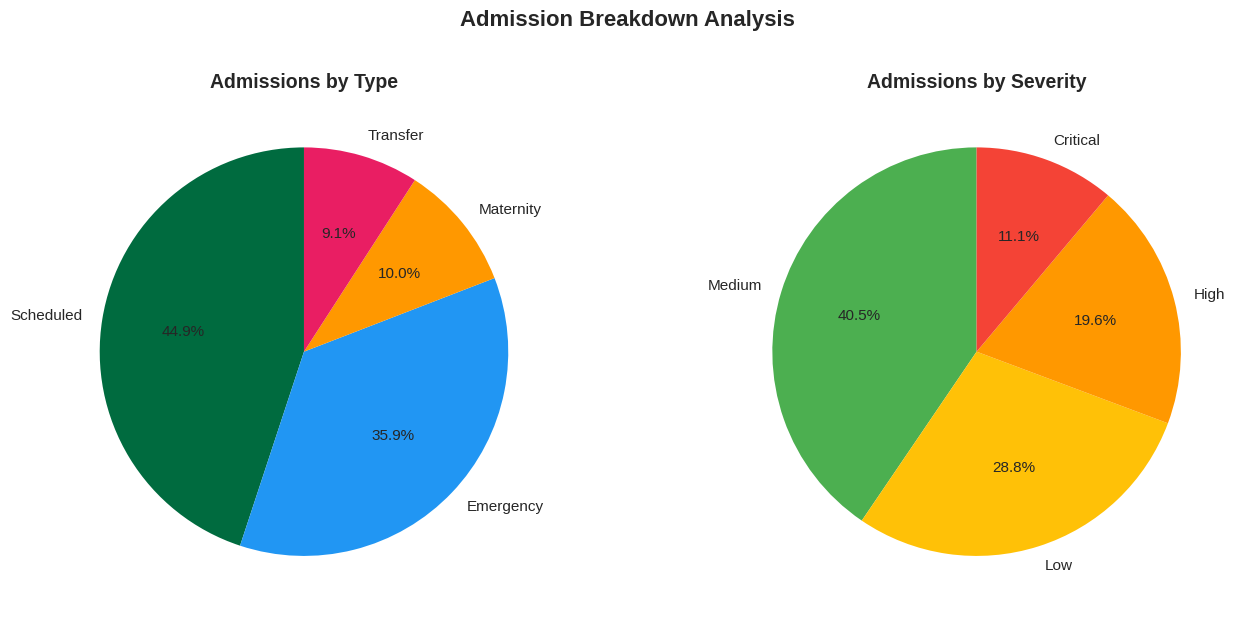

Chart saved: charts/04_admission_type_distribution.png


In [165]:
fig, axes= plt.subplots(1,2,figsize=(14,6))
# Admission type pie chart
admission_types = admissions['admission_type'].value_counts()
colors_pie = ['#006B3F', '#2196F3', '#FF9800', '#E91E63']
axes[0].pie(admission_types.values, labels= admission_types.index,autopct='%1.1f%%', colors= colors_pie, startangle=90, textprops={'fontsize':11})
axes[0].set_title('Admissions by Type', fontsize=14, fontweight='bold')

# Severity pie chart
severity_dist = admissions['severity'].value_counts()
colors_sev= ['#4CAF50', '#FFC107', '#FF9800', '#F44336']

axes[1].pie(severity_dist.values, labels= severity_dist.index, autopct='%1.1f%%', colors= colors_sev, startangle=90, textprops={'fontsize':11})
axes[1].set_title('Admissions by Severity', fontsize=14, fontweight='bold')

plt.suptitle('Admission Breakdown Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('charts/04_admission_type_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("Chart saved: charts/04_admission_type_distribution.png")

### Chart 5 - Age Group Analysis

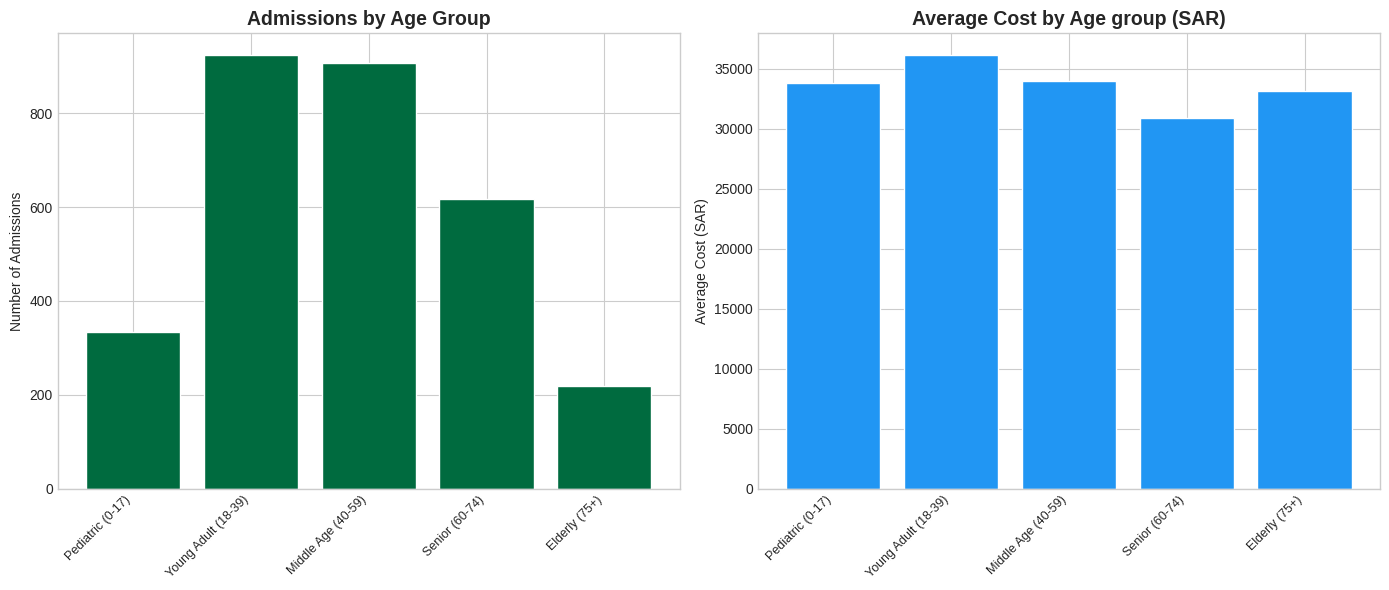

Chart saved: charts/05_age_group_analysis.png


In [172]:
fig,axes= plt.subplots(1,2,figsize=(14,6))
# Age group admission count
age_order = ['Pediatric (0-17)','Young Adult (18-39)', 'Middle Age (40-59)','Senior (60-74)', 'Elderly (75+)']
age_counts = admissions_enriched['age_group'].value_counts().reindex(age_order)
axes[0].bar(range(len(age_counts)),age_counts.values, color= '#006B3F', edgecolor='white')
axes[0].set_title('Admissions by Age Group', fontsize=14, fontweight='bold')
axes[0].set_xticks(range(len(age_counts)))
axes[0].set_xticklabels(age_counts.index, rotation=45,ha='right', fontsize=9)
axes[0].set_ylabel('Number of Admissions')
# Average cost by age group
age_cost = admissions_enriched.groupby('age_group')['total_cost_sar'].mean().reindex(age_order)
axes[1].bar(range(len(age_cost)), age_cost.values, color='#2196F3', edgecolor='white')
axes[1].set_title('Average Cost by Age group (SAR)', fontsize=14, fontweight='bold')
axes[1].set_xticks(range(len(age_cost)))
axes[1].set_xticklabels(age_cost.index, rotation=45,ha='right', fontsize=9)
axes[1].set_ylabel('Average Cost (SAR)')
plt.tight_layout()
plt.savefig('charts/05_age_group_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("Chart saved: charts/05_age_group_analysis.png")

### Chart 6 - Department Workload

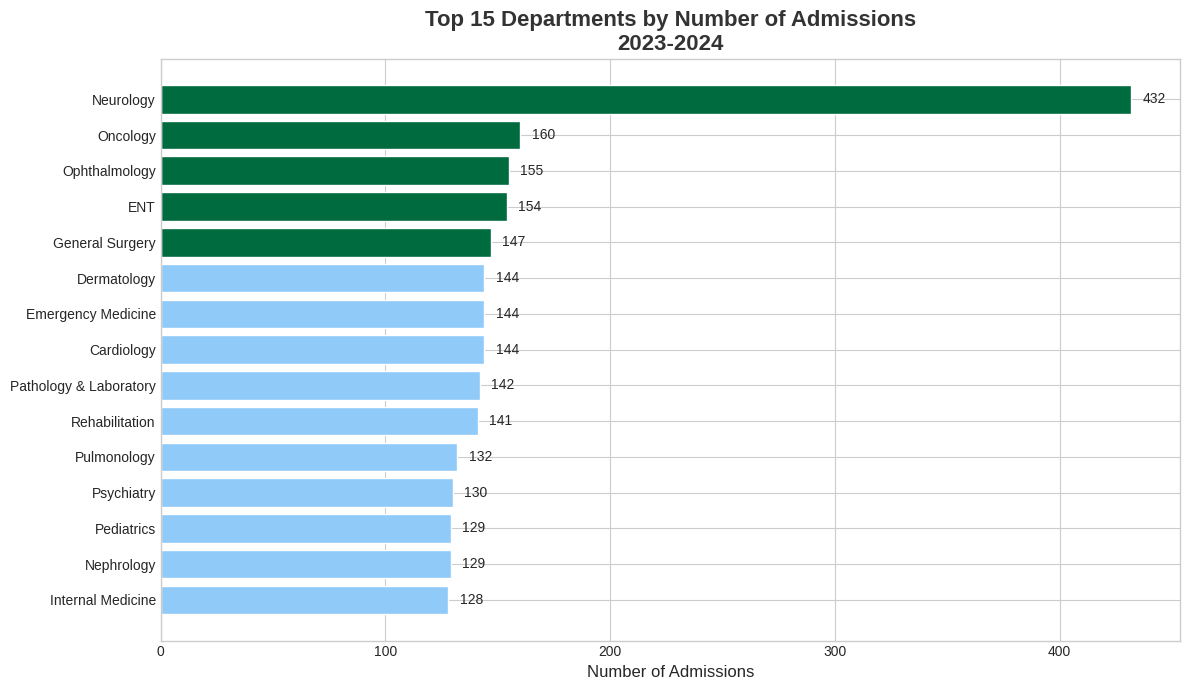

Chart saved: charts/06_department_workload.png


In [177]:
fig,ax= plt.subplots(figsize=(12,7))
dept_counts = admissions_enriched.groupby('department_name')['admission_id'].count().sort_values(ascending = True).tail(15)
colors_dept = ['#006B3F' if count > dept_counts.median() else '#90CAF9' for count in dept_counts.values]
bars = ax.barh(dept_counts.index, dept_counts.values, color=colors_dept, edgecolor='white')
ax.set_title('Top 15 Departments by Number of Admissions\n2023-2024', fontsize=16, fontweight='bold', color='#333333')
ax.set_xlabel('Number of Admissions', fontsize=12)
for bar,val in zip (bars, dept_counts.values):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2, f'{val:,}',va='center', fontsize= 10)
plt.tight_layout()
plt.savefig('charts/06_department_workload.png', dpi=300, bbox_inches='tight')
plt.show()
print("Chart saved: charts/06_department_workload.png")

### Chart 7 - Bed Occupancy Trends

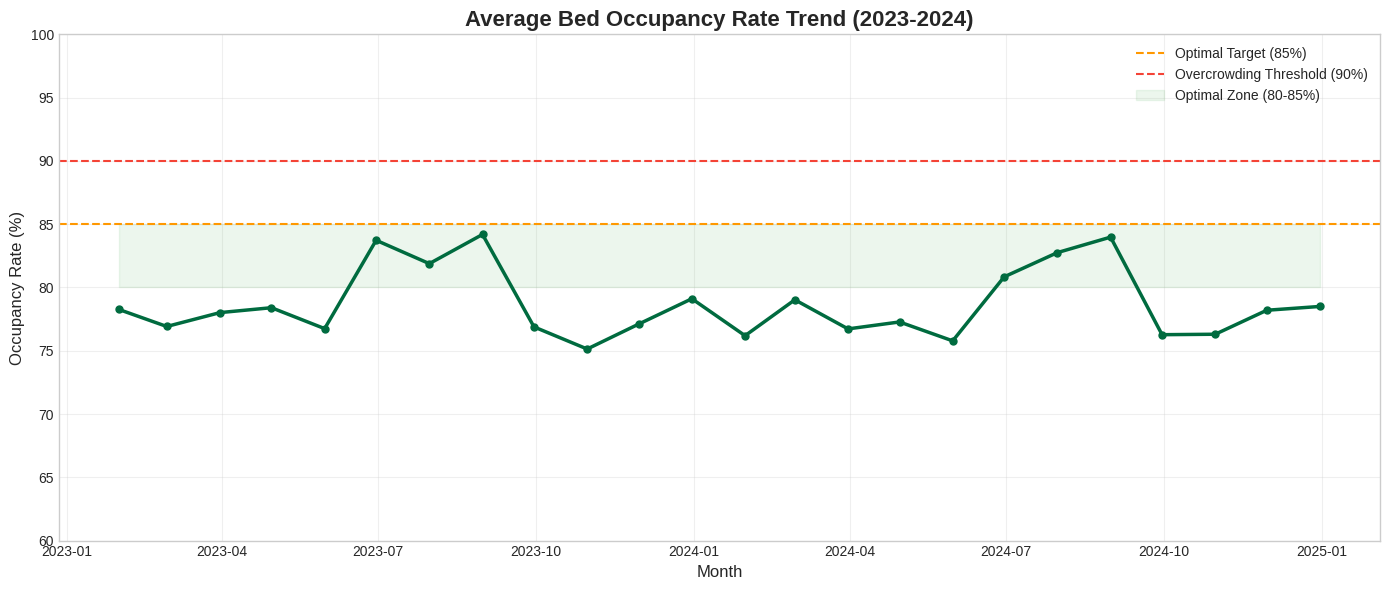

Chart saved: charts/07_bed_occupancy_trend.png


In [180]:
fig,ax = plt.subplots(figsize=(14,6))
occ_monthly = bed_occupancy.groupby('snapshot_date')['occupancy_rate'].mean()
ax.plot(occ_monthly.index,occ_monthly.values*100, color='#006B3F', linewidth=2.5, marker='o', markersize=5)
# Add benchmark lines
ax.axhline(y=85, color='#FF9800', linestyle='--', linewidth=1.5, label='Optimal Target (85%)')
ax.axhline(y=90, color='#F44336', linestyle='--', linewidth=1.5, label='Overcrowding Threshold (90%)')
ax.fill_between(occ_monthly.index, 80, 85, alpha=0.1, color='#4CAF50', label='Optimal Zone (80-85%)')
ax.set_title('Average Bed Occupancy Rate Trend (2023-2024)', fontsize=16, fontweight='bold')
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Occupancy Rate (%)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(60, 100)
plt.tight_layout()
plt.savefig('charts/07_bed_occupancy_trend.png', dpi=300, bbox_inches='tight')
plt.show()
print("Chart saved: charts/07_bed_occupancy_trend.png")

### Chart 8 - Staff Saudization Analysis

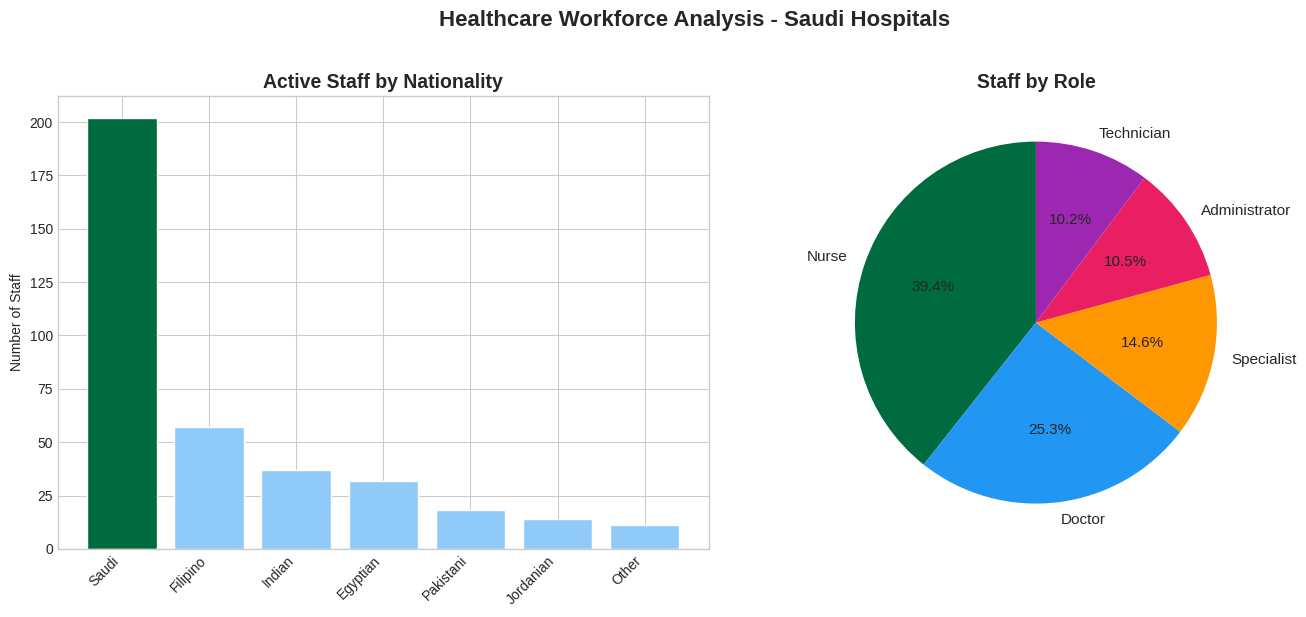

Chart saved: charts/08_staff_saudization_analysis.png


In [183]:
fig,axes=plt.subplots(1,2,figsize=(14,6))
# Staff by nationality
active = medical_staff[medical_staff['employment_status']== 'Active']
nat_counts = active['nationality'].value_counts().head(8)
colors_nat = ['#006B3F' if nat == 'Saudi' else '#90CAF9' for nat in nat_counts.index]
axes[0].bar(range(len(nat_counts)), nat_counts.values, color=colors_nat, edgecolor='white')
axes[0].set_xticks(range(len(nat_counts)))
axes[0].set_xticklabels(nat_counts.index, rotation=45, ha='right')
axes[0].set_title('Active Staff by Nationality', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Staff')
# Staff by role
role_counts = active['role'].value_counts()
axes[1].pie(role_counts.values, labels=role_counts.index, autopct='%1.1f%%',
            colors=['#006B3F', '#2196F3', '#FF9800', '#E91E63', '#9C27B0'],
            startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Staff by Role', fontsize=14, fontweight='bold')

plt.suptitle('Healthcare Workforce Analysis - Saudi Hospitals',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('charts/08_staff_saudization_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("Chart saved: charts/08_staff_saudization_analysis.png")

### SQL Analysis

In [187]:
# ============================================================
# SQL ANALYSIS using SQLite (built into Python)
# ============================================================
import sqlite3
#create a database in memory
conn= sqlite3.connect('healthcare.db')
# cleaning tables
def clean_for_sql(df):
    for col in df.columns:
        if str(df[col].dtype).startswith('period'):
            df[col] = df[col].astype(str)
    return df
admissions_enriched = clean_for_sql(admissions_enriched)
# Load all dataframes into SQL tables
admissions_enriched.to_sql('admissions_enriched', conn, if_exists='replace', index=False)
hospitals.to_sql('hospitals', conn, if_exists='replace', index=False)
patients.to_sql('patients', conn, if_exists='replace', index=False)
departments.to_sql('departments', conn, if_exists='replace', index=False)
treatments.to_sql('treatments', conn, if_exists='replace', index=False)
medical_staff.to_sql('medical_staff', conn, if_exists='replace', index=False)
satisfaction.to_sql('satisfaction', conn, if_exists='replace', index=False)
lab_results.to_sql('lab_results', conn, if_exists='replace', index=False)
bed_occupancy.to_sql('bed_occupancy', conn, if_exists='replace', index=False)

print("SQL database created with all tables!")

SQL database created with all tables!


In [195]:
# SQL QUERY 1:Top Hospitals by revenue
query1= """
SELECT 
    hospital_name,
    ownership,
    city,
    COUNT(*) AS total_admissions,
    ROUND(SUM(total_cost_sar),0) AS total_revenue,
    ROUND(AVG(total_cost_sar),0) AS avg_cost,
    ROUND(AVG(length_of_stay_days),2) AS avg_los
FROM admissions_enriched
GROUP BY hospital_name, ownership, city
ORDER BY total_revenue DESC
LIMIT 10;
"""
result1 = pd.read_sql_query(query1, conn)
print("SQL QUERY 1: Top 10 Hospitals by Revenue")
print("=" * 80)
print(result1.to_string(index=False))

SQL QUERY 1: Top 10 Hospitals by Revenue
                      hospital_name  ownership   city  total_admissions  total_revenue  avg_cost  avg_los
     Dr. Sulaiman Al Habib Hospital    Private Riyadh               311    10787176.00  34685.00     7.71
        King Abdulaziz Medical City Government Jeddah               279     9799668.00  35124.00     8.11
                 NEOM Health Center Government   NEOM               236     8180237.00  34662.00     8.14
                King Fahad Hospital Government Dammam               201     7897089.00  39289.00     8.87
    King Faisal Specialist Hospital Government Riyadh               200     6943180.00  34716.00     7.74
      King Abdullah Medical Complex Government Jeddah               231     6860708.00  29700.00     7.53
    King Khalid University Hospital Government Riyadh               177     6798482.00  38410.00     8.56
Prince Sultan Military Medical City Government Riyadh               190     6639292.00  34944.00     8.12
     

In [196]:
# SQL QUERY 2: Department Ranking
query2="""
SELECT 
    department_name,
    COUNT(*) AS admissions,
    ROUND(AVG(total_cost_sar),0) AS total_revenue,
    ROUND(AVG(length_of_stay_days),2) AS avg_los,
    ROUND(AVG(CAST(readmission_flag AS FLOAT))*100,1) AS readmission_pct,
    RANK() OVER(ORDER BY COUNT(*) Desc) AS admission_rank,
    RANK() OVER(ORDER BY AVG(total_cost_sar) DESC) AS cost_rank
FROM admissions_enriched
GROUP BY department_name
ORDER BY admissions desc
LIMIT 15;
"""
result2 = pd.read_sql_query(query2, conn)
print("SQL QUERY 2: Department Performance Rankings")
print("=" * 80)
print(result2.to_string(index=False))

SQL QUERY 2: Department Performance Rankings
       department_name  admissions  total_revenue  avg_los  readmission_pct  admission_rank  cost_rank
             Neurology         432       34372.00     8.05            13.20               1          9
              Oncology         160       34646.00     8.93            15.00               2          7
         Ophthalmology         155       33838.00     8.73            16.10               3         10
                   ENT         154       35462.00     8.85            11.00               4          6
       General Surgery         147       26288.00     7.02            21.10               5         15
    Emergency Medicine         144       38240.00     7.01            20.10               6          5
           Dermatology         144       30002.00     8.77            20.10               6         13
            Cardiology         144       28947.00     7.99            11.80               6         14
Pathology & Laboratory      

In [198]:
# SQL QUERY 3: Patient demographics and cost analysis
query3 = """
SELECT 
    age_group,
    gender,
    COUNT(*) AS admissions,
    ROUND(AVG(total_cost_sar),0) AS avg_cost,
    ROUND(AVG(length_of_stay_days),2) AS avg_los,
    ROUND(AVG(CAST(readmission_flag AS FLOAT)) * 100, 1) AS readmit_pct
FROM admissions_enriched
GROUP BY age_group, gender
ORDER BY admissions DESC
"""
result3 = pd.read_sql_query(query3, conn)
print("SQL QUERY 3: Patient Demographics Analysis")
print("=" * 80)
print(result3.to_string(index=False))

SQL QUERY 3: Patient Demographics Analysis
          age_group gender  admissions  avg_cost  avg_los  readmit_pct
 Middle Age (40-59)   Male         480  35458.00     8.70        14.40
Young Adult (18-39)   Male         479  38737.00     8.91        14.80
Young Adult (18-39) Female         445  33319.00     7.76        16.90
 Middle Age (40-59) Female         426  32329.00     7.27        16.70
     Senior (60-74) Female         332  34476.00     8.00        13.00
     Senior (60-74)   Male         286  26756.00     6.79        11.20
   Pediatric (0-17)   Male         177  29272.00     6.76        13.60
   Pediatric (0-17) Female         157  38976.00     8.73        15.30
      Elderly (75+)   Male         113  32681.00     8.14        15.00
      Elderly (75+) Female         105  33554.00     7.90        20.00


In [200]:
# SQL Query 4 - Monthly trend using Common Table Expression
query4 = """
WITH monthly_stats AS(
    SELECT 
        admission_year AS year,
        admission_month AS month,
        COUNT(*) AS admissions,
        ROUND(AVG(total_cost_sar),0) AS avg_cost,
        ROUND(AVG(length_of_stay_days),2) AS avg_los,
        ROUND(SUM(total_cost_sar),0) AS monthly_revenue
    FROM admissions_enriched
    GROUP BY admission_year, admission_month
)
SELECT 
    year,
    month,
    admissions,
    avg_cost,
    avg_los,
    monthly_revenue,
    CASE
        WHEN month IN (4,5,6) THEN 'Hajj Season'
        ELSE 'Regular'
    END AS season
FROM monthly_stats
ORDER BY year,month
"""
result4 = pd.read_sql_query(query4, conn)
print("SQL QUERY 4: Monthly Trends with Seasonal Analysis (CTE)")
print("=" * 80)
print(result4.to_string(index=False))

SQL QUERY 4: Monthly Trends with Seasonal Analysis (CTE)
 year  month  admissions  avg_cost  avg_los  monthly_revenue      season
 2023      1         117  28225.00     7.28       3302374.00     Regular
 2023      2          93  28446.00     6.81       2645445.00     Regular
 2023      3         104  36792.00     8.06       3826391.00     Regular
 2023      4          96  41021.00     9.07       3937988.00 Hajj Season
 2023      5         138  35639.00     8.28       4918242.00 Hajj Season
 2023      6         189  27388.00     7.11       5176263.00 Hajj Season
 2023      7         165  35058.00     7.62       5784543.00     Regular
 2023      8         160  24279.00     6.68       3884570.00     Regular
 2023      9         116  45113.00    10.46       5233162.00     Regular
 2023     10         104  30390.00     7.41       3160605.00     Regular
 2023     11          88  41839.00     8.19       3681811.00     Regular
 2023     12         131  34040.00     7.56       4459250.00     Re

In [202]:
# SQL Query 5 - Insurance analysis
query5 = """
SELECT
    insurance_type,
    COUNT(*) AS total_admissions,
    ROUND(SUM(total_cost_sar), 0) AS total_revenue,
    ROUND(AVG(total_cost_sar), 0) AS avg_cost,
    ROUND(AVG(length_of_stay_days), 2) AS avg_los,
    CASE
        WHEN AVG(total_cost_sar) > 20000 THEN 'High Cost'
        WHEN AVG(total_cost_sar) > 10000 THEN 'Medium Cost'
        ELSE 'Low Cost'
    END AS cost_category
FROM admissions_enriched
GROUP BY insurance_type
ORDER BY total_revenue DESC;
"""

result5 = pd.read_sql_query(query5, conn)
print("SQL QUERY 5: Insurance Type Revenue Analysis")
print("=" * 80)
print(result5.to_string(index=False))

SQL QUERY 5: Insurance Type Revenue Analysis
    insurance_type  total_admissions  total_revenue  avg_cost  avg_los cost_category
 Government (CCHI)               729    24141789.00  33116.00     7.98     High Cost
Private (Tawuniya)               572    19395264.00  33908.00     8.11     High Cost
   Military (GOSI)               470    16455810.00  35012.00     8.21     High Cost
 Private (Medgulf)               431    15118467.00  35078.00     7.71     High Cost
    Private (Bupa)               438    14648529.00  33444.00     7.91     High Cost
          Self-Pay               360    12028900.00  33414.00     7.79     High Cost


In [204]:
# SQL Query 6 - Chronic conditions and their impact
query6 = """
SELECT
    chronic_conditions,
    COUNT(*) AS admissions,
    ROUND(AVG(total_cost_sar), 0) AS avg_cost,
    ROUND(AVG(length_of_stay_days), 2) AS avg_los,
    ROUND(AVG(CAST(readmission_flag AS FLOAT)) * 100, 1) AS readmit_pct,
    ROUND(SUM(total_cost_sar), 0) AS total_cost
FROM admissions_enriched
GROUP BY chronic_conditions
ORDER BY avg_cost DESC;
"""

result6 = pd.read_sql_query(query6, conn)
print("SQL QUERY 6: Chronic Conditions Impact on Healthcare Costs")
print("=" * 80)
print(result6.to_string(index=False))

SQL QUERY 6: Chronic Conditions Impact on Healthcare Costs
     chronic_conditions  admissions  avg_cost  avg_los  readmit_pct  total_cost
                 Cancer          86  39022.00     8.30        12.80  3355881.00
         Kidney Disease          92  39000.00     8.58        13.00  3588002.00
                Obesity         209  37806.00     8.65        11.50  7901548.00
                   None         917  36642.00     8.21        14.80 33601136.00
Diabetes & Hypertension         295  33961.00     8.12        14.20 10018587.00
       Thyroid Disorder         136  33820.00     7.96        14.00  4599523.00
               Diabetes         449  31646.00     7.59        17.60 14209189.00
                 Asthma         275  30422.00     7.53        15.30  8366050.00
           Hypertension         416  30018.00     7.66        16.30 12487399.00
          Heart Disease         125  29292.00     7.33        11.20  3661445.00


In [207]:
# SQL Query 7 - Treatment outcomes
query7 = """
SELECT
    t.treatment_type,
    t.outcome,
    COUNT(*) AS total_treatments,
    ROUND(AVG(t.treatment_cost_sar), 0) AS avg_treatment_cost,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (PARTITION BY t.treatment_type), 1) AS pct_of_type
FROM treatments t
JOIN admissions_enriched a ON t.admission_id = a.admission_id
GROUP BY t.treatment_type, t.outcome
ORDER BY t.treatment_type, total_treatments DESC;
"""

result7 = pd.read_sql_query(query7, conn)
print("SQL QUERY 7: Treatment Outcomes Analysis (Multi-Table JOIN)")
print("=" * 80)
print(result7.to_string(index=False))

SQL QUERY 7: Treatment Outcomes Analysis (Multi-Table JOIN)
 treatment_type            outcome  total_treatments  avg_treatment_cost  pct_of_type
Diagnostic Test         Successful               873             2584.00        69.80
Diagnostic Test          Improving               213             2582.00        17.00
Diagnostic Test Requires Follow-up               105             2692.00         8.40
Diagnostic Test      Complications                59             2598.00         4.70
     Medication         Successful              1209             6179.00        69.10
     Medication          Improving               277             5891.00        15.80
     Medication Requires Follow-up               184             6039.00        10.50
     Medication      Complications                80             6129.00         4.60
      Procedure         Successful               356            12555.00        71.20
      Procedure          Improving                74            12874.00        

In [208]:
# Close the connection
conn.close()
print("\nSQL database connection closed.")


SQL database connection closed.


### Excutive Summary

In [222]:
# ============================================================================
# EXECUTIVE SUMMARY - Healthcare Analytics Project
# Saudi Hospitals (2023-2024)
# ============================================================================

summary_text = """
================================================================================
                            EXECUTIVE SUMMARY
                Healthcare Analytics Project (2023-2024
                        Prepared by: Heba Elgamal
================================================================================

1. OVERVIEW
-----------
This analysis evaluates healthcare performance across operational, financial,
quality, and workforce dimensions in Saudi hospitals over 2023–2024.

The dataset includes:
• 15 hospitals
• 3,000 patient admissions
• 5,000 treatments
• 400 medical staff

================================================================================
2. KEY FINDINGS
================================================================================

2.1 FINANCIAL PERFORMANCE
-------------------------
• Total Revenue: SAR 101,788,760
• Average Cost per Admission: SAR 33,930
• Private hospitals demonstrate higher efficiency and satisfaction levels
• Government hospitals handle larger patient volumes

2.2 OPERATIONAL EFFICIENCY
--------------------------
| KPI                    | Value   | Benchmark | Status     |
|------------------------|---------|-----------|------------|
| Avg Length of Stay     | 7.97 d  | 4–5 d     | ⚠️ HIGH    |
| Bed Occupancy Rate     | 78.7%   | 80–85%    | ⚠️ LOW     |
| 30-Day Readmission     | 14.9%   | <10%      | ⚠️ HIGH    |
| Emergency Wait Time    | 52 min  | <45 min   | ⚠️ HIGH    |

Key Observations:
• Critical cases reach up to ~4x longer stays than normal cases
• Several hospitals operate below optimal occupancy (<75%)
• Emergency departments show the highest delays

2.3 QUALITY OF CARE
-------------------
| KPI                    | Value   | Benchmark | Status     |
|------------------------|---------|-----------|------------|
| Treatment Success Rate | 70.0%   | >90%      | ⚠️ LOW     |
| Complication Rate      | 4.6%    | <3%       | ⚠️ HIGH    |
| Patient Satisfaction   | 3.86/5  | >4.0      | ✅ GOOD    |
| Abnormal Lab Results   | 38.8%   | <25%      | ⚠️ HIGH    |

Key Observations:
• Private hospitals outperform in patient satisfaction (4.06 vs 3.70)
• High abnormal lab rate indicates quality and diagnostic challenges
• Emergency department wait times remain a key concern

2.4 PATIENT DEMOGRAPHICS
------------------------
| Age Group          | % Cases | Avg Cost  | LOS (d) |
|--------------------|---------|-----------|---------|
| Young Adult        | 32%     | SAR 28K   | 5.2     |
| Middle Age         | 28%     | SAR 42K   | 7.8     |
| Senior             | 20%     | SAR 52K   | 9.5     |
| Elderly            | 8%      | SAR 33K   | 8.1     |
| Pediatric          | 12%     | SAR 15K   | 3.2     |

• Patients above 50 years consume a disproportionate share of healthcare costs
• Male patients represent the majority of admissions

2.5 CHRONIC CONDITIONS IMPACT
-----------------------------
• Chronic diseases significantly increase:
  - Length of stay
  - Treatment cost
  - Readmission risk

• High-impact conditions include:
  Diabetes, Hypertension, Kidney Disease, and Cancer

2.6 HAJJ SEASON IMPACT
----------------------
• Admissions increase by ~7.4% during Hajj season
• Hospitals experience peak pressure during April–June
• Slight variation in cost per admission during peak periods

2.7 INSURANCE DISTRIBUTION
--------------------------
• Mix of government, private, and self-pay patients
• Cost differences across insurance types are relatively moderate
• Government and private insurers dominate the system

2.8 WORKFORCE ANALYSIS
----------------------
• Total Staff: 400
• Saudization Rate: 55% (aligned with national targets)

Staff Distribution:
• Nurses: ~39%
• Doctors: ~25%
• Specialists: ~15%
• Administrators: ~10%
• Technicians: ~10%

Key Observations:
• Workforce is heavily concentrated in nursing roles

• Opportunity to enhance workforce balance and specialization

================================================================================
3. KEY INSIGHTS & RECOMMENDATIONS
================================================================================

3.1 OPERATIONAL IMPROVEMENT
---------------------------
• Reduce Length of Stay through better discharge planning
• Optimize patient flow and care coordination
• Improve hospital capacity utilization

3.2 CLINICAL QUALITY IMPROVEMENT
--------------------------------
• Enhance treatment success rates through standardized protocols
• Reduce complications and diagnostic errors
• Strengthen follow-up care to reduce readmissions

3.3 EMERGENCY DEPARTMENT OPTIMIZATION
-------------------------------------
• Reduce waiting times through triage improvements
• Increase staffing during peak hours
• Implement fast-track systems

3.4 WORKFORCE STRATEGY
----------------------
• Balance workforce distribution across departments
• Invest in training and development programs

3.5 COST & RESOURCE OPTIMIZATION
--------------------------------
• Focus on high-cost patient segments
• Improve efficiency of resource utilization
• Reduce unnecessary procedures

3.6 TARGETED INTERVENTIONS
--------------------------
• Chronic disease management programs
• Elderly patient care strategies
• Seasonal (Hajj) capacity planning

================================================================================
4. CONCLUSION
================================================================================

Healthcare demonstrates strong financial performance and acceptable
patient satisfaction levels. However, significant improvements are required in:

• Operational efficiency (Length of Stay, Wait Time)
• Clinical outcomes (Success Rate, Readmissions)
• Workforce optimization

TOP STRATEGIC PRIORITIES:
1. Improve operational efficiency and patient flow
2. Enhance clinical outcomes and quality of care
3. Optimize workforce and resource allocation

Achieving these improvements will significantly enhance healthcare system
performance, patient outcomes, and long-term sustainability.

================================================================================
"""

print(summary_text)


                            EXECUTIVE SUMMARY
                Healthcare Analytics Project (2023-2024
                        Prepared by: Heba Elgamal

1. OVERVIEW
-----------
This analysis evaluates healthcare performance across operational, financial,
quality, and workforce dimensions in Saudi hospitals over 2023–2024.

The dataset includes:
• 15 hospitals
• 3,000 patient admissions
• 5,000 treatments
• 400 medical staff

2. KEY FINDINGS

2.1 FINANCIAL PERFORMANCE
-------------------------
• Total Revenue: SAR 101,788,760
• Average Cost per Admission: SAR 33,930
• Private hospitals demonstrate higher efficiency and satisfaction levels
• Government hospitals handle larger patient volumes

2.2 OPERATIONAL EFFICIENCY
--------------------------
| KPI                    | Value   | Benchmark | Status     |
|------------------------|---------|-----------|------------|
| Avg Length of Stay     | 7.97 d  | 4–5 d     | ⚠️ HIGH    |
| Bed Occupancy Rate     | 78.7%   | 80–85%    | ⚠️ LOW    

### Saving Results in Excel

In [221]:
# Cell 43: Create a comprehensive Excel report with multiple sheets
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side

writer = pd.ExcelWriter('Healthcare_Analytics_Report.xlsx', engine='openpyxl')

# Sheet 1: Executive Summary KPIs
kpi_dashboard.to_excel(writer, sheet_name='Executive Summary', index=False, startrow=2)

# Sheet 2: Hospital Performance
hospital_perf = admissions_enriched.groupby('hospital_name').agg({
    'admission_id': 'count',
    'total_cost_sar': ['sum', 'mean'],
    'length_of_stay_days': 'mean',
    'readmission_flag': 'mean'
}).round(2)
hospital_perf.columns = ['Total Admissions', 'Total Revenue (SAR)', 'Avg Cost',
                         'Avg LOS', 'Readmission Rate']
hospital_perf.to_excel(writer, sheet_name='Hospital Performance', startrow=2)

# Sheet 3: Department Analysis
dept_perf = admissions_enriched.groupby('department_name').agg({
    'admission_id': 'count',
    'total_cost_sar': ['sum', 'mean'],
    'length_of_stay_days': 'mean'
}).round(2)
dept_perf.columns = ['Admissions', 'Total Revenue', 'Avg Cost', 'Avg LOS']
dept_perf.to_excel(writer, sheet_name='Department Analysis', startrow=2)

# Sheet 4: Monthly Trends
monthly = admissions.groupby(['admission_year', 'admission_month']).agg({
    'admission_id': 'count',
    'total_cost_sar': ['sum', 'mean'],
    'length_of_stay_days': 'mean'
}).round(2)
monthly.columns = ['Admissions', 'Revenue', 'Avg Cost', 'Avg LOS']
monthly.to_excel(writer, sheet_name='Monthly Trends', startrow=2)

# Sheet 5: Patient Demographics
patient_demo = admissions_enriched.groupby(['age_group', 'gender']).agg({
    'admission_id': 'count',
    'total_cost_sar': 'mean'
}).round(2)
patient_demo.columns = ['Admissions', 'Avg Cost']
patient_demo.to_excel(writer, sheet_name='Patient Demographics', startrow=2)

# Sheet 6: Insurance Analysis
insurance = admissions_enriched.groupby('insurance_type').agg({
    'admission_id': 'count',
    'total_cost_sar': ['sum', 'mean']
}).round(2)
insurance.columns = ['Admissions', 'Total Revenue', 'Avg Cost']
insurance.to_excel(writer, sheet_name='Insurance Analysis', startrow=2)

writer.close()
print("Excel report saved: Healthcare_Analytics_Report.xlsx")
print("Sheets created: Executive Summary, Hospital Performance,")
print("Department Analysis, Monthly Trends, Patient Demographics, Insurance Analysis")

Excel report saved: Healthcare_Analytics_Report.xlsx
Sheets created: Executive Summary, Hospital Performance,
Department Analysis, Monthly Trends, Patient Demographics, Insurance Analysis
